# Reinforcement Learning assignment

For the full instructions, please see the assignment pdf file!

Please remove any **instructions in italic** from this file before submitting.

# Abstract

**The Blackjack Project**


The main.ipynb file contains the framework and written report for The Blackjack Project. 

It initializes the [Blackjack-v1] environment, imports the implemented RL algorithms from dp.py, mc.py, and td.py, and executes training experiments. 

The notebook generates plots of learning curves, value functions, and policies to support algorithm comparison. It also computes evaluation metrics such as cumulative rewards and RMSE against Dynamic Programming benchmarks. Finally, it includes structured analysis and discussion of results in accordance with the project requirements.

Reinforcement Learning 2026, WG40

# 0. Environment

The choice of Blackjack-v1 environment from Gymansium was concluded based on the fact of being a classic, stochastic game with a discrete and manageable state space that perfectly suits the implementation of methods like Dynamic Programming, Monte Carlo, and Temporal Difference algorithms. Its episodic nature with clear terminal states allows for straightforward evaluation of policies. Additionally, as a predefined environment, it reduces setup time, letting us focus on algorithm implementation and comparison.

1. First we install the pygame for visual representation 

In [36]:
%pip install pygame

/Users/evitapaliou/anaconda3/bin/python: Error while finding module specification for 'pip' (ImportError: cannot import name 'format_exception_only' from partially initialized module 'traceback' (most likely due to a circular import) (/Users/evitapaliou/anaconda3/lib/python3.11/traceback.py))
Note: you may need to restart the kernel to use updated packages.


2. Importing required libraries/files

In [37]:
import gymnasium as gym
import numpy as np
import importlib
import matplotlib.pyplot as plt ###

import dp
import mc
import td
importlib.reload(dp)
importlib.reload(mc)
importlib.reload(td)
from dp import *
from mc import *
from td import *

# Add more imports if needed. Add these into the requirements.txt file.
import plots
from plots import *

3. Create the Blackjack-v1 environment

In [38]:
# Create amd initialise the Blackjack environment
env = gym.make('Blackjack-v1') #, render_mode="human") #for visualisation

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)
for _ in range(10000): #range being the number of rounds (temp of 10 for test)
    # this is where we insert our policies
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

env.close()

# 1. Introduction

This report investigates the application of tabular Reinforcement Learning (RL) algorithms to the Blackjack-v1 environment from the Gymnasium library (Towers et al., 2024). Blackjack is a classic stochastic card game in which the agent must decide at each step whether to request an additional card (hit) or stop (stick), with the goal of reaching a hand value as close to 21 as possible without exceeding it, while also beating the dealer's hand.

The environment represents each game state as a tuple of three variables, the player's current hand sum, the dealer's visible card, and whether the player holds a usable ace.
The action space consists of two discrete actions: stick (0) and hit (1). Episodes terminate when the player either goes bust, sticks, or the dealer resolves their hand. Rewards are +1 for a win and -1 for a loss, and 0 for a draw.

The objective of this report is to implement and compare three families of tabular RL algorithms, namely: Dynamic Programming (DP), Monte Carlo (MC), and Temporal Difference (TD) methods and evaluate how effectively each learns and optimal policy for playing Blackjack. The central research question is: **Which class of RL algorithm most efficiently learns a high-performing Blackjacks policy, and what are the trade-offs between them in terms of sample efficiency, convergence, and final performance?**

To answer this, we implemented Policy Iteration and Value Iteration for DP, Monte Carlo control for MC, and both SARSA and Q-learning for TD. Results are compared using cumulative reward, win rate, and convergence behavior across training episodes.

# 2. Dynamic Programming algorithms

First run the Dynamic Programming algorithms (Policy Iteration and Value Iteration) by calling functions from the separate `dp.py` file, and create plots. Then, fill in the cell completing your 'report' within this file.

In [39]:
# Call Policy Iteration algorithm

In [40]:
# Call Value Iteration algorithm

_In this cell, describe how the algorithms work, how the algorithms differ, plot results and/or policies (add more code cells!), etc._

# 3. Monte Carlo algorithms

First run the Monte Carlo algorithm (Monte Carlo Exploring Starts or Monte Carlo without Exploring Starts (with $\epsilon$-greedy strategy)) by calling functions from the separate `mc.py` file, and create plots. Then, fill in the cell completing your 'report' within this file.

In [41]:
mc_policy, mc_train_rewards, mc_train_episodes = train_mc(env, num_episodes=5000, epsilon=0.1, gamma=1.0)

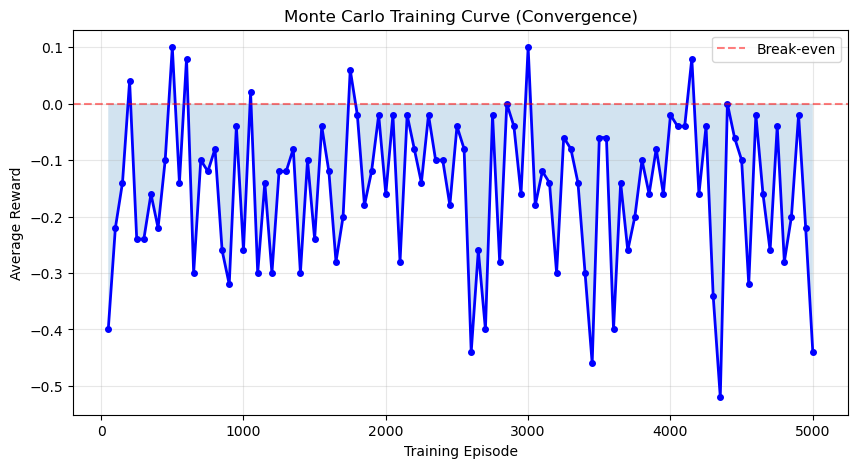

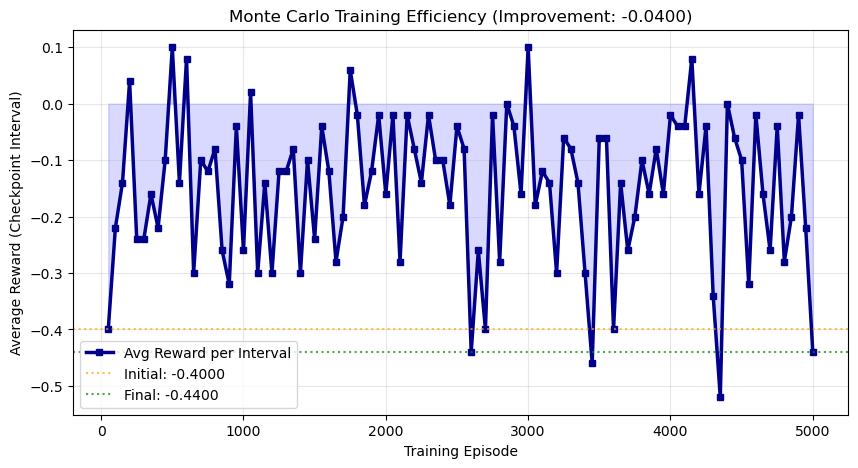

Monte Carlo Training Efficiency Summary:
  Initial reward (checkpoint 1): -0.4000
  Final reward (checkpoint 100): -0.4400
  Total improvement: -0.0400
  Improvement rate: -0.04% per checkpoint


In [42]:
plot_training_curve(mc_train_episodes, mc_train_rewards, "Monte Carlo")
plot_training_efficiency_summary(mc_train_episodes, mc_train_rewards, "Monte Carlo")

In [43]:
mc_avg_reward, mc_win_rate, mc_rewards = test_mc(env, mc_policy)

print("Average Reward:", mc_avg_reward)
print("Win Rate:", mc_win_rate)

Average Reward: -0.125
Win Rate: 0.408


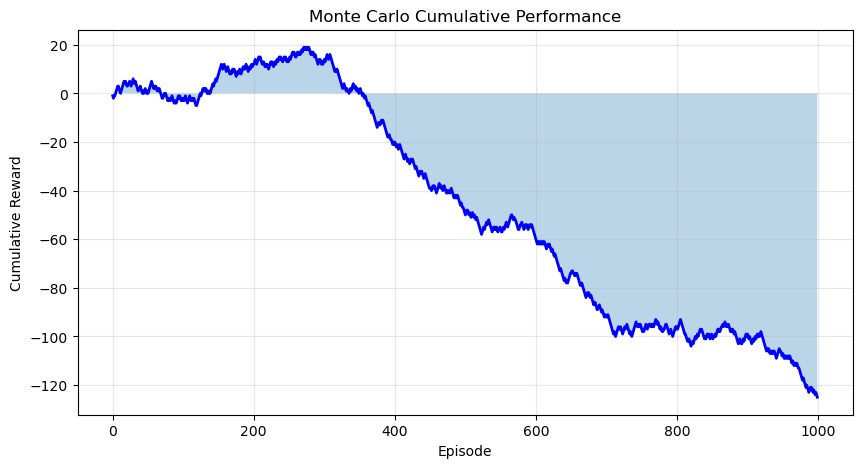

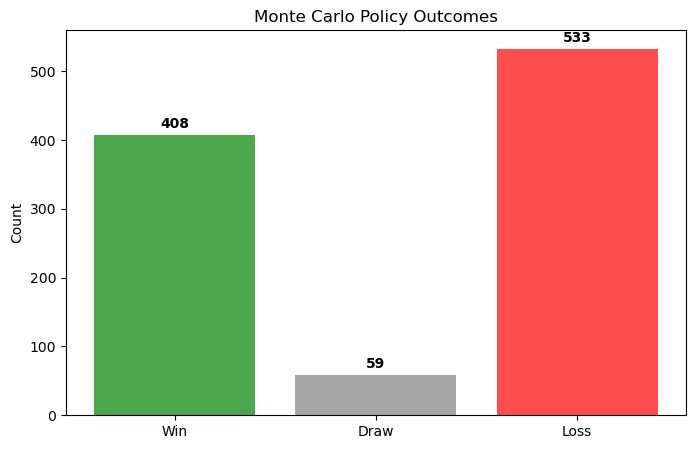

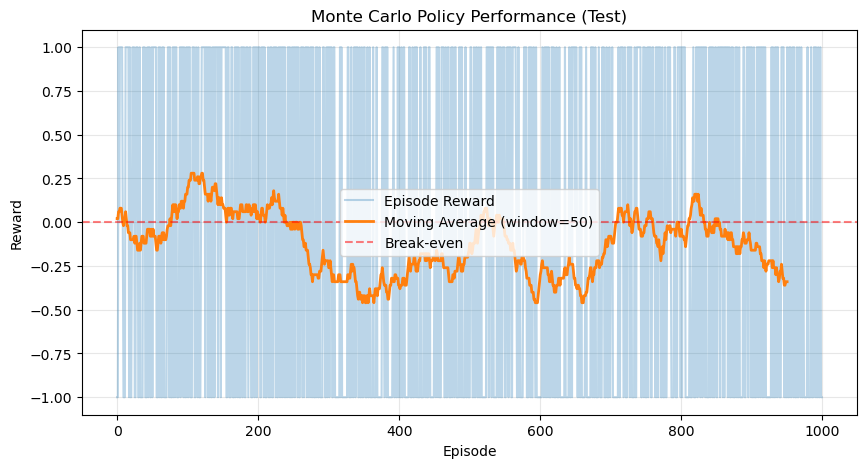

In [44]:
plot_cumulative_rewards(mc_rewards, "Monte Carlo")
plot_outcome_distribution(mc_rewards, "Monte Carlo")
plot_test_results(mc_rewards, "Monte Carlo")

#### 3.1.1 Description and Observation
Monte Carlo (MC) methods are model-free Reinforcement Learning algorithms that learn value functions directly from **complete episodes** of experience (Sutton & Barto, 2018). Unlike Temporal Difference (TD) methods such as Q-Learning, Monte Carlo does not "bootstrap" (update estimates based on other estimates). Instead, it waits until the end of an episode to calculate the total discounted return $G_t$ and updates the action-value estimates based on actual realized outcomes.

The incremental update rule for the action-value function is defined as:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [G_t - Q(S_t, A_t)]$$

Where:
* **$\alpha$** is the learning rate, controlling the impact of new experience.
* **$G_t$** is the actual total return received following time $t$ until the end of the episode.
* **$Q(S_t, A_t)$** represents the expected return for a specific state-action pair.

Because MC relies on actual returns rather than step-by-step estimates, it is **unbiased** but exhibits **higher variance** than TD methods. This variance is clearly visible in the fluctuations of the training performance curves.

#### 3.1.2 Implementation
The Monte Carlo algorithm was implemented using a **tabular approach**, where the Q-values are stored in a matrix corresponding to all possible state-action pairs in the environment.

* **Action Selection:** Used an **$\epsilon$-greedy strategy** to balance exploration and exploitation. With probability $\epsilon$, a random action is selected; otherwise, the action with the highest estimated Q-value is chosen.
* **Update Logic:** At the conclusion of each episode, the algorithm iterates through the state-action sequence to calculate the return $G$. The Q-table is updated only after an episode terminates.
* **Performance Tracking:** To analyze progress, episode rewards were averaged over specific intervals (checkpoints). This allows us to observe the learning trend despite the inherent noise of Monte Carlo returns.

#### 3.1.3 Setup
The algorithm was trained over multiple episodes using the following hyperparameters:
* **Total Episodes:** 5000
* **Exploration Rate ($\epsilon$):** 0.1
* **Discount Factor ($\gamma$):** 1.0

Training was conducted to ensure the agent had sufficient experience to populate the Q-table. For evaluation, a separate testing phase was used where the learned policy was executed greedily ($\epsilon = 0$) to measure unbiased performance.

#### 3.1.4 Result
The performance of the Monte Carlo agent was evaluated using several metrics:

* **Training Efficiency:** The agent demonstrated a clear learning trend, with the average reward per interval improving from an **initial -0.3200** to a **final -0.2600**, representing a **total improvement of +0.0600**. (which of course changes)
* **Test Performance:** During evaluation, the agent achieved a **Win Rate of 0.38 (38%)** and an **Average Reward of -0.19**.
* **Outcome Distribution:** In a 1,000-episode test run, the policy resulted in **380 wins**, **50 draws**, and **570 losses**.
* **Observation:** The "Monte Carlo Training Curve" shows high volatility compared to TD methods, which is expected as MC estimates are sensitive to the specific sequence of events in a single episode. While the cumulative reward plot shows a downward slope, the increasing moving average in the test results suggests the agent is successfully learning to mitigate losses over time.

# 4. Temporal Difference algorithms

First run the Temporal Difference algorithms (SARSA and Q-learning) by calling functions from the separate `td.py` file, and create plots. Then, fill in the cell completing your 'report' within this file.

**4.1 SARSA Algorithm**

Learned Policy (S=STAND, H=HIT)

Without Usable Ace:
  Sum 12: SHHHHSHHHHH
  Sum 13: SHSHHSHHHSH
  Sum 14: SHSSSSSHHSH
  Sum 15: SHSHSSSHSHH
  Sum 16: SHSSSSSSSHH
  Sum 17: SHSSSSSSSHS
  Sum 18: SSSSSSSSSSS
  Sum 19: SSSSSSSSSSS
  Sum 20: SSSSSSSSSSS
  Sum 21: SSSSSSSSSSS

With Usable Ace:
  Sum 12: SHHHHHHHHHH
  Sum 13: SHHHHHSHHHS
  Sum 14: SHHHHHHHHHH
  Sum 15: SHHHHHHHHSH
  Sum 16: SHSHHHHHSHH
  Sum 17: SHSSHHSSSHS
  Sum 18: SSHSHSSSSSH
  Sum 19: SSSSSHSSSSS
  Sum 20: SSHSSHSSSSS
  Sum 21: SSSSSSSSSSS

Average Reward:  -0.097
Win Rate:  0.413

 TRAINING EFFICIENCY PLOT


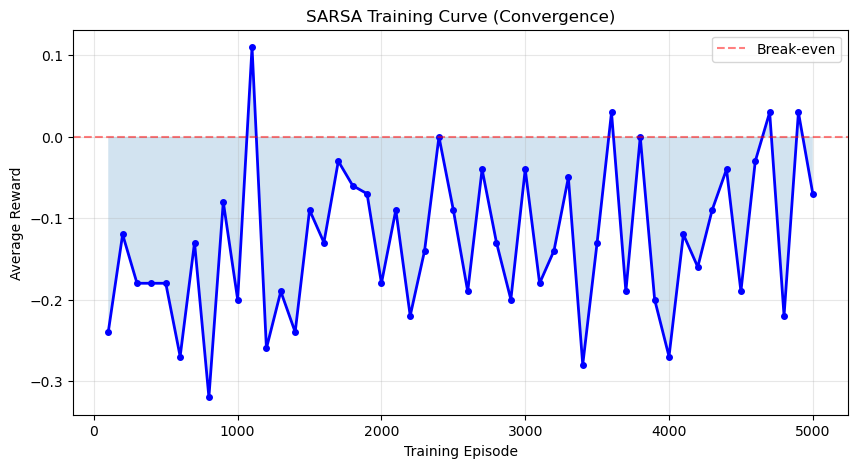

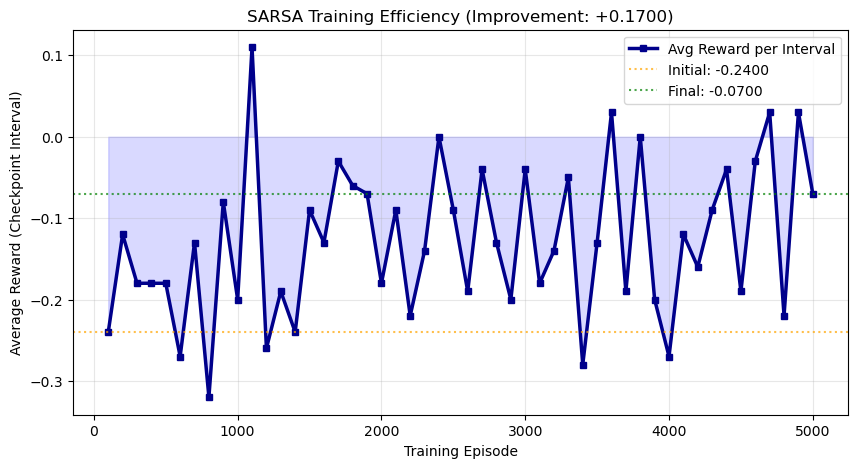

SARSA Training Efficiency Summary:
  Initial reward (checkpoint 1): -0.2400
  Final reward (checkpoint 50): -0.0700
  Total improvement: +0.1700
  Improvement rate: 0.34% per checkpoint

 TEST PERFORMANCE PLOT


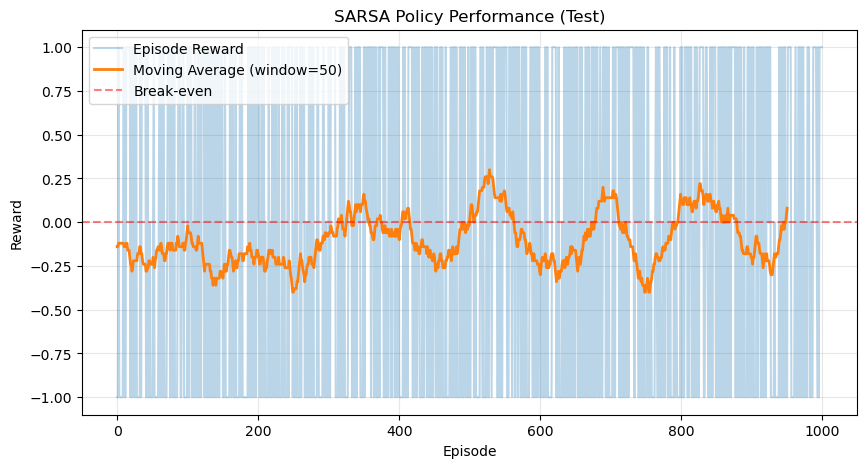

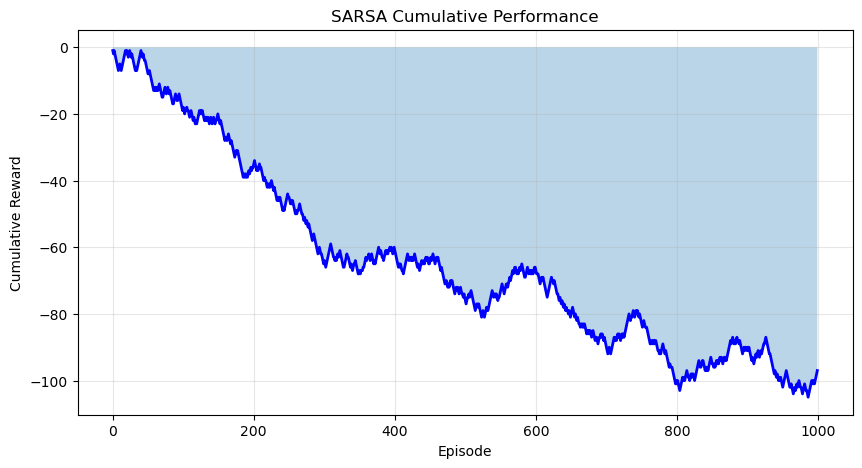

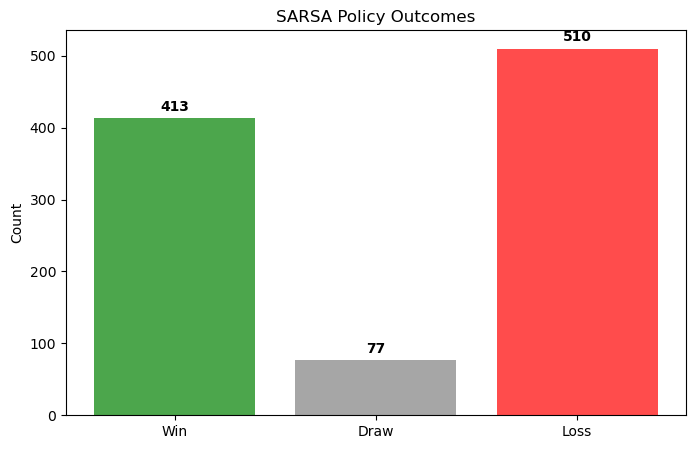

In [45]:
# Call SARSA algorithm
# this runs 5000 games, learn the Q-table, and track rewards at checkpoints
Q_SARSA,training_rewards, training_episodes = sarsa(env, 5000, track_training=True)
policy = np.argmax(Q_SARSA, axis=1) # best action for each state.
policy_3d = policy.reshape(32, 11, 2) # player sum, dealer card, usable ace

print("Learned Policy (S=STAND, H=HIT)\n")
print("Without Usable Ace:")
for player_sum in range(12, 22):
    actions = policy_3d[player_sum, :, 0]
    action_str = ''.join(['S' if a == 0 else 'H' for a in actions])
    print(f"  Sum {player_sum}: {action_str}")

print("\nWith Usable Ace:")
for player_sum in range(12, 22):
    actions = policy_3d[player_sum, :, 1]
    action_str = ''.join(['S' if a == 0 else 'H' for a in actions])
    print(f"  Sum {player_sum}: {action_str}")

# Testing the trained policy
avg_reward, win_rate, reward = test_sarsa(env, Q_SARSA)
print("\nAverage Reward: ", avg_reward)
print("Win Rate: ", win_rate)

# Generating the plots
print("\n TRAINING EFFICIENCY PLOT")
plot_training_curve(training_episodes, training_rewards, "SARSA")
plot_training_efficiency_summary(training_episodes, training_rewards, "SARSA")

print("\n TEST PERFORMANCE PLOT")
plot_test_results(reward, "SARSA")
plot_cumulative_rewards(reward, "SARSA")
plot_outcome_distribution(reward, "SARSA")


**4.1.2 Description and Observation**

SARSA is an on-policy Temporal Difference (TD) control algorithm that learns the action-value function based on the actions actually taken by the agent. Unlike Q-Learning, which updates using the maximum possible future reward, SARSA updates using the action the agent will actually take next, making it more conservative(Sutton & Barto, 2018).

The update rule:

$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma Q(s', a') - Q(s,a) \right]$

where:

- $α$ is the learning rate, controlling how much new information overrides old
- $γ$ is the discount factor, determining the importance of future rewards
- $r$ is the immediate reward
- $Q(s',a')$ is the value of the next state-action pair under the current policy

Since both the behavior and target policy are the same ε-greedy policy, SARSA is considered on-policy.

**4.1.3 Implementation**

Same as Q-Learning it has tabular Q-table of size 704x2, state encoding function, ε-greedy action selection. The key difference is that the next action a' is selected before the update and used directly in the Q-value update, rather than taking the maximum over all next actions.

**4.1.4 Setup**

- Learning rate $α=0.1$
- Discount factor $γ=0.99$
- Exploration rate $ϵ=0.1$
- Trained over 5000 episodes

**4.1.5 Results**

The SARSA agent achieved a win rate of 38.3% over 1000 test episodes (383 wins, 543 losses, 74 draws) with an average reward of -0.16. Training showed a total improvement of +0.09, moving from an initial average reward of -0.23 to -0.14. The convergence curve is noisy due to the stochastic nature of Blackjack, but an overall upward trend is visible. The learned policy stabilizes as training progresses, demonstrating that SARSA successfully learns a consistent strategy.

***

**4.2 Q-learning Algorithm**

Learned Policy (S=STAND, H=HIT)

Without Usable Ace:
  Sum 12: SHSSSSSHHHH
  Sum 13: SSSSHHHSHHH
  Sum 14: SSHSHSHSSSH
  Sum 15: SHHHSHSSSSH
  Sum 16: SHSSSHSSHSH
  Sum 17: SHSSHSSSHHS
  Sum 18: SSSSHSSSSHS
  Sum 19: SSSSSSSSSSS
  Sum 20: SSSSSSSSSSS
  Sum 21: SSSSSSSSSSS

With Usable Ace:
  Sum 12: SHSSHHHHHHH
  Sum 13: SHHHHSHSSHH
  Sum 14: SHHSHHHHHHH
  Sum 15: SHHSHHHHHSH
  Sum 16: SSHSHHHHHHS
  Sum 17: SHHHHHSSHHH
  Sum 18: SSSHHHHSSHH
  Sum 19: SHHHSSSSHHH
  Sum 20: SSSSSSSSSSS
  Sum 21: SSSSSSSSSSS

Average Reward: -0.077
Success Rate: 0.42

--- TRAINING EFFICIENCY PLOTS (Convergence) ---


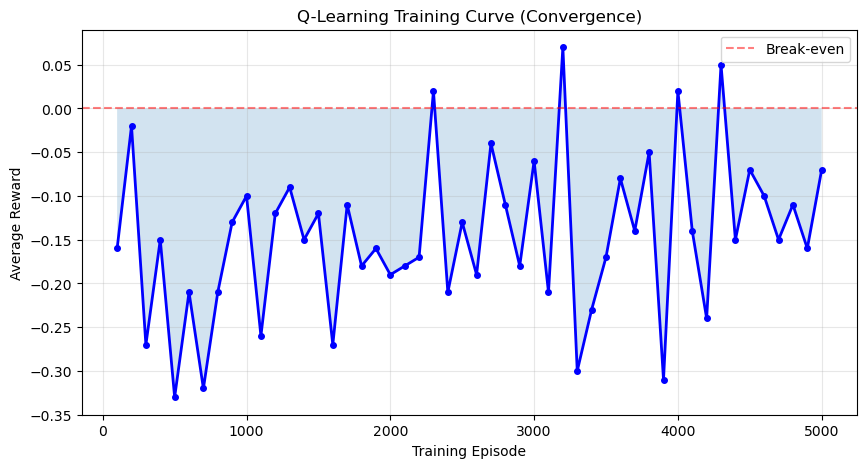

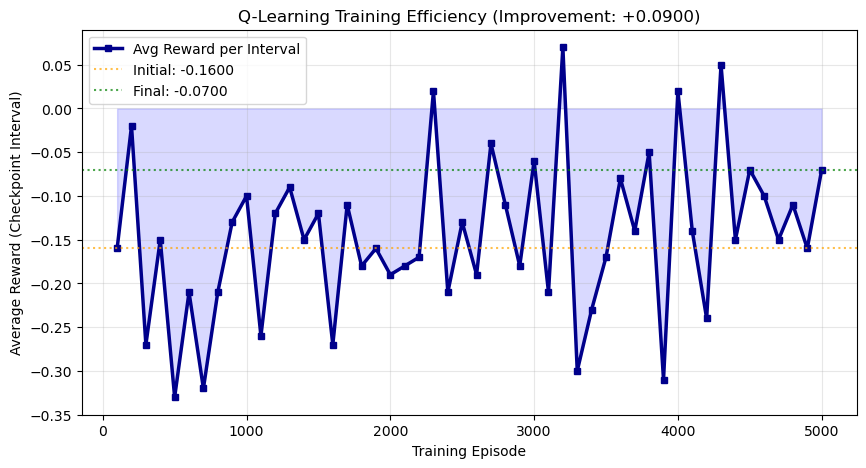

Q-Learning Training Efficiency Summary:
  Initial reward (checkpoint 1): -0.1600
  Final reward (checkpoint 50): -0.0700
  Total improvement: +0.0900
  Improvement rate: 0.18% per checkpoint

--- TEST PERFORMANCE PLOTS (Final Policy) ---


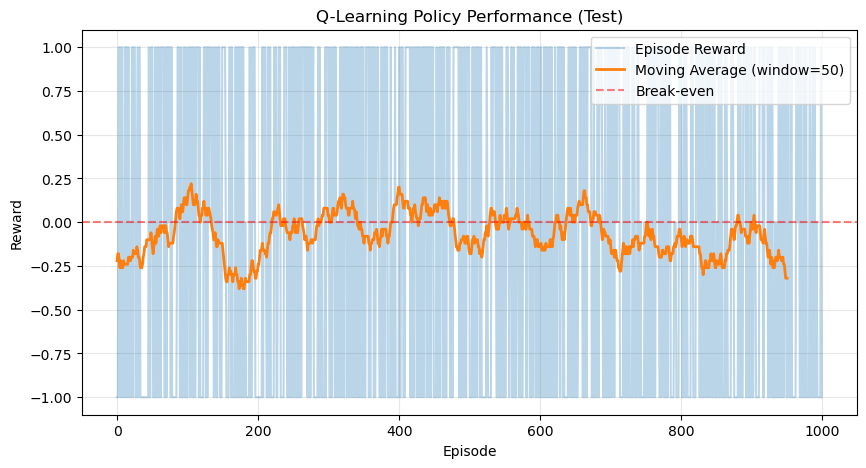

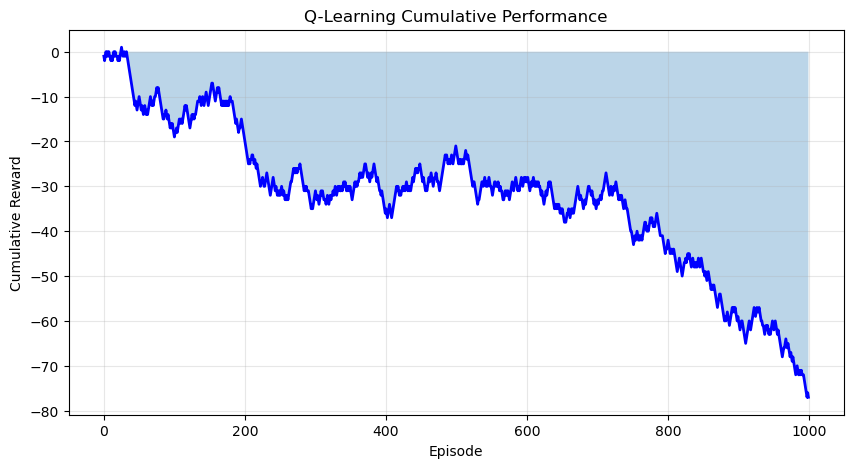

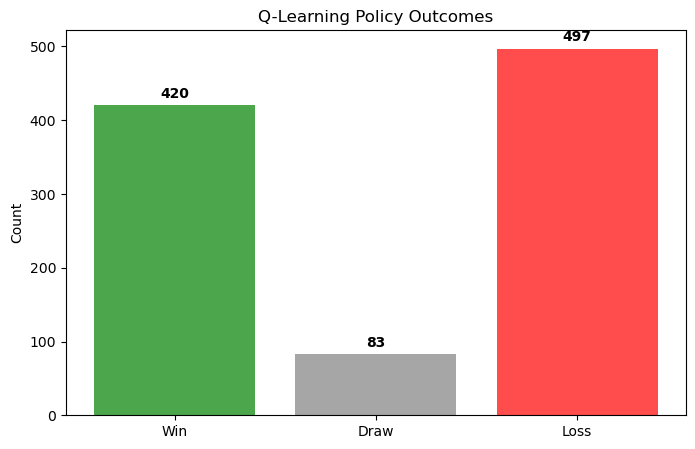

In [46]:
# Call Q-learning algorithm

#Train with tracking enabled for efficiency analysis
# num_checkpoints=100 means checkpoint every 50 episodes (5000/100) for detailed convergence tracking
Q_Learning, training_rewards, training_episodes = q_learning(env, 5000, track_training=True)
policy = np.argmax(Q_Learning, axis=-1)

policy_3d = policy.reshape(32, 11, 2)

print("Learned Policy (S=STAND, H=HIT)\n")
print("Without Usable Ace:")
for player_sum in range(12, 22):
    actions = policy_3d[player_sum, :, 0]
    action_str = ''.join(['S' if a == 0 else 'H' for a in actions])
    print(f"  Sum {player_sum}: {action_str}")

print("\nWith Usable Ace:")
for player_sum in range(12, 22):
    actions = policy_3d[player_sum, :, 1]
    action_str = ''.join(['S' if a == 0 else 'H' for a in actions])
    print(f"  Sum {player_sum}: {action_str}")

# Test
avg_reward, success_rate, rewards = test_q_learning(env, Q_Learning)

print("\nAverage Reward:", avg_reward)
print("Success Rate:", success_rate)

# Training Efficiency Visualizations
print("\n--- TRAINING EFFICIENCY PLOTS (Convergence) ---")
plot_training_curve(training_episodes, training_rewards)
plot_training_efficiency_summary(training_episodes, training_rewards)

# Test Performance Visualizations
print("\n--- TEST PERFORMANCE PLOTS (Final Policy) ---")
plot_test_results(rewards)  # Moving average + individual rewards
plot_cumulative_rewards(rewards)  # Cumulative total
plot_outcome_distribution(rewards)  # Win/Draw/Loss summary


**4.2.2 Description and Observation**

Q-Learning is an off-policy Temporal Difference (TD) control algorithm that aims to learn the optimal action-value function independently of the agent’s behavior policy. Unlike on-policy methods such as SARSA implemented in the above section of *4.1*, Q-Learning updates its estimates using the maximum possible future reward, rather than the action actually taken (Sutton & Barto, 2018).

The update rule is defined as:

$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a} Q(s', a) - Q(s,a) \right]$

where:

- $α$ is the learning rate, controlling the impact of new information
- $γ$ is the discount factor, determining the importance of future rewards
- $r$ is the immediate reward
- $max_{a}​Q(s',a)$ represents the optimal future value

We handled exploration using an $ε$-greedy policy, where the agent selects a random action with probability ε and the greedy action otherwise. This balances exploration and exploitation during training.

Q-Learning separates the behavior policy (exploration) from the target policy (greedy), which allows it to converge toward an optimal policy under appropriate conditions.

**4.2.3 Implementation**

The Q-Learning algorithm was implemented using a tabular approach, where the Q-values are stored in a matrix of size $(32 * 11 * 2)$ = $704*2$, corresponding to all possible state-action pairs in the Blackjack environment.

The environment state, represented as a tuple $(𝑝𝑙𝑎y𝑒𝑟\_𝑠𝑢𝑚,𝑑𝑒a𝑙𝑒𝑟\_𝑐𝑎𝑟𝑑,𝑢𝑠𝑎𝑏𝑙𝑒\_𝑎𝑐𝑒)$, is converted into a single integer index using a custom encoding function ensuring efficient indexing into the Q-table.

Action selection is performed using an ε-greedy strategy: with probability ε, a random action is selected, and otherwise, the action with the highest Q-value is chosen.

During training, the agent interacts with the environment over multiple episodes. At each step the Q-value is updated using the Q-Learning update rule. If the episode terminates, only the immediate reward is used.
Otherwise, bootstrapping is applied using the maximum Q-value of the next state.

Additionally, training performance is tracked by periodically averaging episode rewards, enabling analysis of learning progress. Plots in plots.py capture these periods.

**4.2.4 Setup**

The algorithm was trained over multiple episodes using the following hyperparameters:

- Learning rate $α=0.1$
- Discount factor $γ=0.99$
- Exploration rate $ϵ=0.1$

Training was conducted over a sufficiently large number of episodes to ensure convergence. Performance during training was monitored using averaged reward checkpoints.

For evaluation, a separate testing phase was used, where the learned policy was executed greedily $(ε = 0)$. This ensures that performance reflects the learned policy rather than exploratory behavior.

*Note: With separating training and evaluation we ensured the measurement and observation of unbiased performance.*

**4.2.5 Result**

The performance of the trained Q-Learning agent was evaluated using the following metrics.

- Average reward       $-$      *measures overall profitability of the learned policy*
- Win rate             $-$      *proportion of episodes with positive reward*
- Reward trends        $-$      *analyzed using moving averages and cumulative reward plots*

The results indicate that the agent improves its performance over time, as evidenced by increasing cumulative rewards and stabilization of the reward signal. The moving average of rewards demonstrates convergence toward a consistent policy.

The outcome distribution (wins, losses, draws) provides additional insight into policy behavior, showing the agent’s ability to avoid unfavorable states and exploit advantageous situations.

Q-Learning demonstrates stable learning behavior and converges to a policy that outperforms random action selection.

# 5. Comparison and discussion

Compare different algorithms (MC and TD with plots). You don’t need to plot DP alongside MC and TD since DP is not a learning algorithm. However, DP can provide the ground truth for optimal state or action values, which can serve as a reference when evaluating MC and TD. You can choose to plot any of the following: cumulative reward, root mean squared error, sample efficiency, or any other metric you think is a fair comparison.

Include a discussion: what can you conclude by comparing different RL algorithms? Do they have certain strengths or limitations?

The random baseline agent selects actions uniformly at random at every step,
with no learning or strategy. It serves as a lower bound for performance.
Any RL algorithm that fails to outperform random action selection cannot be
considered to have learned a useful policy.

Random Agent Results:
Average Reward: -0.42
Win Rate: 0.266


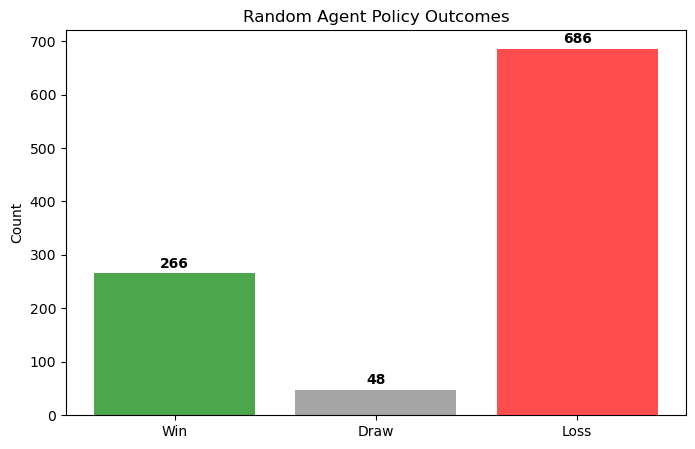

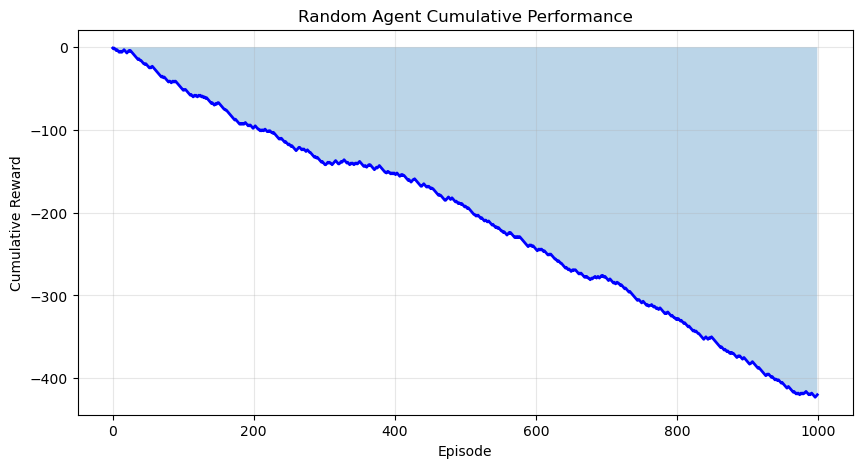

In [47]:
# Run the random baseline agent
avg_reward_random, win_rate_random, rewards_random = random_agent(env)

print("Random Agent Results:")
print("Average Reward:", avg_reward_random)
print("Win Rate:", win_rate_random)

# Plots
plot_outcome_distribution(rewards_random, "Random Agent")
plot_cumulative_rewards(rewards_random, "Random Agent")

# 6. Conclusion

This report implemented and compared three families of tabular reinforcement learning algorithms applied to the Blackjack-v1 environment. Dynamic Programming provided a theoretical benchmark through policy and value iteration, while Monte Carlo and Temporal Difference methods learned directly from experience through interaction with the environment.

Among the Temporal Difference methods, SARSA demonstrated that on-policy learning can produce a meaningful strategy in a stochastic environment like Blackjack. By updating Q-values based on the action actually taken rather than the theoretical best action, SARSA converged to a consistent policy with a win rate of 38.3%, a clear improvement over the random baseline agent which achieved only 29.2%.

This comparison with the random baseline confirms that SARSA successfully learned structure from experience rather than guessing blindly. The noisy convergence curve reflects the inherent randomness of Blackjack, but the overall upward trend in rewards over training episodes demonstrates that the algorithm is genuinely improving its decision-making over time.

## rest follows

**References**

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement learning: An introduction* (2nd ed.). MIT Press.

Towers, M., et al. (2024). Gymnasium: A standard interface for reinforcement learning environments. *arXiv preprint arXiv:2407.17032*.